#📌 Extracción

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
link = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

df = pd.read_json(link)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [4]:
columnas = ['customer', 'phone', 'internet', 'account']
df_norm = df[['customerID', 'Churn']].copy()

for col in columnas:
    normalizar_col = pd.json_normalize(df[col])
    df_norm = pd.concat([df_norm, normalizar_col], axis=1)

df_norm.head()


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

## Conoce el conjunto de datos

In [5]:
df_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [6]:
df_norm.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


## Comprobación de incoherencias en los datos

**Imprimimos los valores únicos de cada columna para revisar inconsistencias**

In [7]:
for col in df_norm.columns:
  print(col)
  print(pd.unique(df_norm[col]))

customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn
['No' 'Yes' '']
gender
['Female' 'Male']
SeniorCitizen
[0 1]
Partner
['Yes' 'No']
Dependents
['Yes' 'No']
tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
PhoneService
['Yes' 'No']
MultipleLines
['No' 'Yes' 'No phone service']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['No' 'Yes' 'No internet service']
OnlineBackup
['Yes' 'No' 'No internet service']
DeviceProtection
['No' 'Yes' 'No internet service']
TechSupport
['Yes' 'No' 'No internet service']
StreamingTV
['Yes' 'No' 'No internet service']
StreamingMovies
['No' 'Yes' 'No internet service']
Contract
['One year' 'Month-to-month' 'Two year']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Mailed check' 'Electronic check' 'Credit card (automati

**En la culumnas "Churn" se nota un valor inconsistente**

In [8]:
pd.unique(df_norm['Churn'])

array(['No', 'Yes', ''], dtype=object)

## Manejo de inconsistencias

**Se reemplazan los valores inconsistentes**

In [9]:
df_norm['Churn'] = df_norm['Churn'].replace('', np.nan)

In [10]:
pd.unique(df_norm['Churn'])

array(['No', 'Yes', nan], dtype=object)

**Se cuentan los datos faltantes**

In [11]:
df_norm["Churn"].isna().sum()

np.int64(224)

**Como las filas sin valor no sirven para el analisis, se eliminan**

In [12]:
df_norm = df_norm.dropna(subset=["Churn"])

In [13]:
df_norm["Churn"].isna().sum()

np.int64(0)

## Columna de cuentas diarias (Opcional)

In [14]:
df_norm["Cuentas_Diarias"] = df_norm["Charges.Monthly"] / 30

In [15]:
df_norm['Cuentas_Diarias']

,Cuentas_Diarias
0,2.186667
1,1.996667
2,2.463333
3,3.266667
4,2.796667
...,...
7262,1.838333
7263,2.836667
7264,1.676667
7265,2.261667


## Estandarización y transformación de datos (opcional)

Los datos de la columna "Charges.Total" son de tipo objet, se convertiran a tipo float64

In [16]:
df_norm["Charges.Total"] = pd.to_numeric(df_norm["Charges.Total"], errors="coerce")

In [17]:
df_norm["Charges.Total"].dtype

dtype('float64')

#📊 Carga y análisis

In [18]:
df_norm[["tenure","Charges.Monthly","Charges.Total","Cuentas_Diarias"]].describe()



,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7032.000000,7043.000000
mean,32.371149,64.761692,2283.300441,2.158723
std,24.559481,30.090047,2266.771362,1.003002
min,0.000000,18.250000,18.800000,0.608333
25%,9.000000,35.500000,401.450000,1.183333
50%,29.000000,70.350000,1397.475000,2.345000
75%,55.000000,89.850000,3794.737500,2.995000
max,72.000000,118.750000,8684.800000,3.958333


In [19]:
df_norm["Contract"].value_counts(normalize=True) * 100
df_norm["PaymentMethod"].value_counts()
df_norm["SeniorCitizen"].value_counts()


,count
SeniorCitizen,
0,5901
1,1142


In [20]:
df_norm.groupby("Churn")["tenure"].mean()
df_norm.groupby("Churn")["Charges.Monthly"].median()
df_norm.groupby("Churn")["Contract"].value_counts(normalize=True)

Churn  Contract      
No     Month-to-month    0.429068
       Two year          0.318322
       One year          0.252609
Yes    Month-to-month    0.885500
       One year          0.088818
       Two year          0.025682
Name: proportion, dtype: float64

/tmp/ipykernel_165/2511987323.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df_norm, palette='viridis')


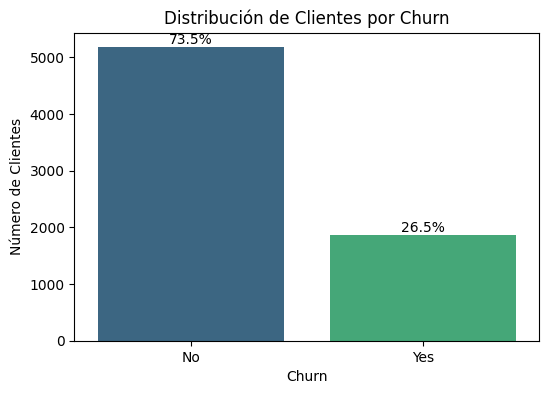

In [24]:

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df_norm, palette='viridis')
plt.title('Distribución de Clientes por Churn')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')

total = len(df_norm['Churn'])
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

Distribución de Churn por Género

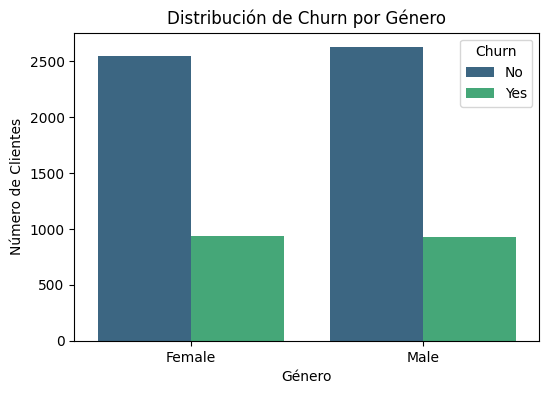

In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_norm, x='gender', hue='Churn', palette='viridis')
plt.title('Distribución de Churn por Género')
plt.xlabel('Género')
plt.ylabel('Número de Clientes')
plt.show()

Distribución de Churn por Tipo de Contrato

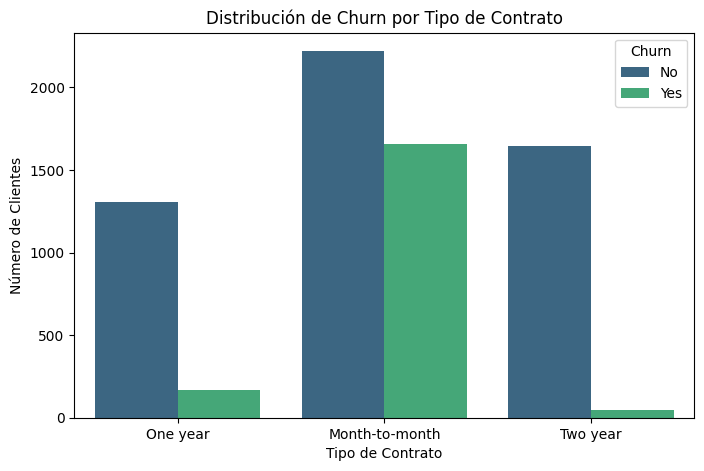

In [29]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_norm, x='Contract', hue='Churn', palette='viridis')
plt.title('Distribución de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de Clientes')
plt.show()

Distribución de Churn por Método de Pago

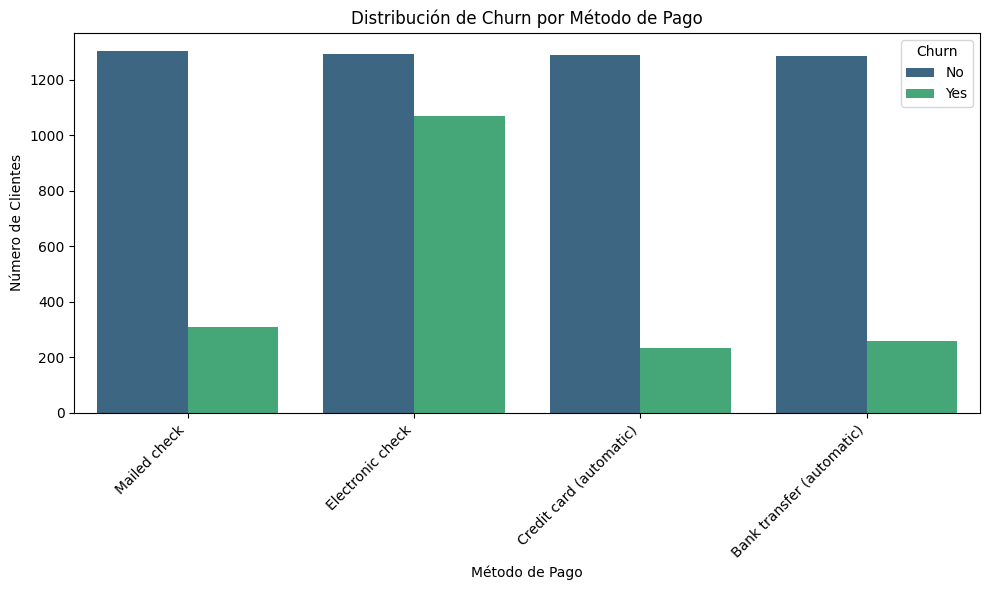

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_norm, x='PaymentMethod', hue='Churn', palette='viridis')
plt.title('Distribución de Churn por Método de Pago')
plt.xlabel('Método de Pago')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Distribución de Churn por Total Gastado (Charges.Total)

/tmp/ipykernel_165/1557643144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_norm, x='Churn', y='Charges.Total', palette='viridis')


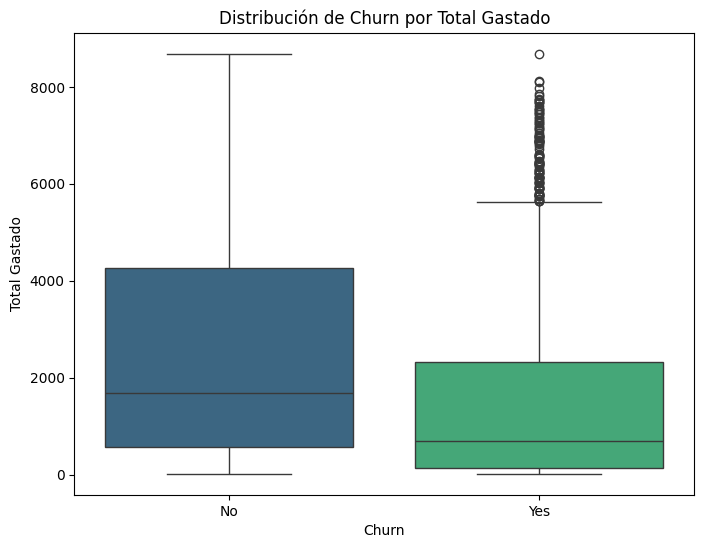

In [33]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_norm, x='Churn', y='Charges.Total', palette='viridis')
plt.title('Distribución de Churn por Total Gastado')
plt.xlabel('Churn')
plt.ylabel('Total Gastado')
plt.show()

Distribución de Churn por Tiempo de Contrato (Tenure)

/tmp/ipykernel_165/2105802072.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_norm, x='Churn', y='tenure', palette='viridis')


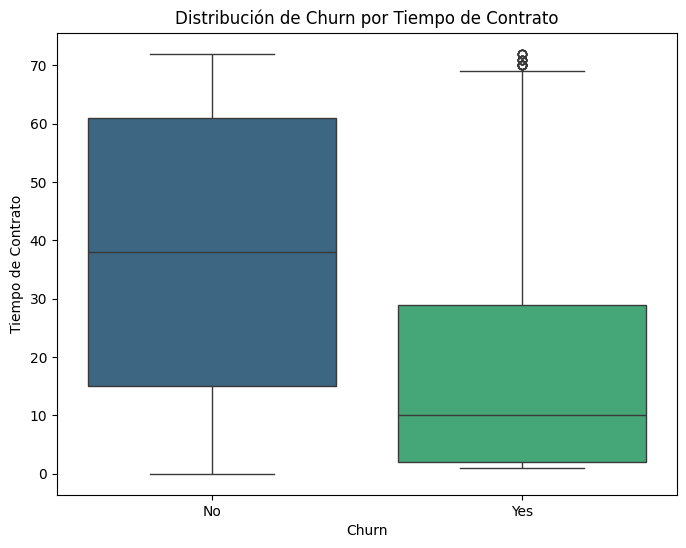

In [34]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_norm, x='Churn', y='tenure', palette='viridis')
plt.title('Distribución de Churn por Tiempo de Contrato')
plt.xlabel('Churn')
plt.ylabel('Tiempo de Contrato')
plt.show()

#📄Informe final

🔹 Introducción
El objetivo de este análisis es comprender los factores que influyen en la 'evasión de clientes' (Churn) en el servicio de telecomunicaciones. El Churn representa la pérdida de clientes, lo que tiene un impacto directo en los ingresos y la sostenibilidad de cualquier negocio. Mediante el análisis de los datos proporcionados, buscamos identificar patrones y características de los clientes que se dan de baja, lo que permitirá desarrollar estrategias para retenerlos y mejorar la satisfacción del cliente.

🔹 Limpieza y Tratamiento de Datos

El proceso de preparación de los datos fue crucial para asegurar la calidad y consistencia del análisis. Los pasos realizados incluyeron:

Carga de Datos: Se cargó el archivo TelecomX_Data.json en un DataFrame de pandas.
Normalización de Estructuras Anidadas: Las columnas 'customer', 'phone', 'internet', y 'account' contenían datos anidados en formato JSON. Se normalizaron estas columnas para expandir sus sub-atributos en nuevas columnas del DataFrame principal (df_norm).
Manejo de Inconsistencias en 'Churn': Se identificaron valores inconsistentes ('') en la columna 'Churn'. Estos valores se reemplazaron por NaN y posteriormente se eliminaron las filas correspondientes, ya que no aportaban información útil para el análisis de Churn.
Creación de la Columna 'Cuentas_Diarias': Se añadió una nueva columna calculando las 'Cuentas_Diarias' dividiendo 'Charges.Monthly' por 30, para ofrecer una perspectiva de los cargos diarios.
Conversión de Tipo de Datos: La columna 'Charges.Total' se convirtió de tipo object a float64 para permitir operaciones numéricas, manejando los errores de conversión con errors='coerce' para convertir valores no válidos a NaN.

## 🔹 Análisis Exploratorio de Datos (EDA)

Se realizaron diversos análisis para explorar la distribución de variables y su relación con la evasión. A continuación, se presentan las visualizaciones más relevantes:

### Distribución General de Clientes por Churn

Se observa que aproximadamente el 26.5% de los clientes han abandonado el servicio, lo que indica un problema significativo de retención.

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df_norm, palette='viridis')
plt.title('Distribución de Clientes por Churn')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')

total = len(df_norm['Churn'])
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

### Distribución de Churn por Género

La distribución de Churn por género no muestra diferencias significativas, lo que sugiere que el género no es un factor determinante en la evasión.

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_norm, x='gender', hue='Churn', palette='viridis')
plt.title('Distribución de Churn por Género')
plt.xlabel('Género')
plt.ylabel('Número de Clientes')
plt.show()

### Distribución de Churn por Tipo de Contrato

Los clientes con contratos mes a mes (`Month-to-month`) tienen una tasa de churn considerablemente más alta en comparación con aquellos con contratos de uno o dos años. Esto indica una mayor lealtad de los clientes con compromisos a largo plazo.

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_norm, x='Contract', hue='Churn', palette='viridis')
plt.title('Distribución de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de Clientes')
plt.show()

### Distribución de Churn por Método de Pago

Los clientes que utilizan el método de pago 'Electronic check' presentan una tasa de churn notablemente superior. Esto podría estar relacionado con la facilidad para cambiar de proveedor o la insatisfacción con el servicio que los lleva a tomar decisiones rápidas.

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_norm, x='PaymentMethod', hue='Churn', palette='viridis')
plt.title('Distribución de Churn por Método de Pago')
plt.xlabel('Método de Pago')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Distribución de Churn por Total Gastado (Charges.Total)

Los clientes que churnean tienden a tener un 'Total Gastado' menor en promedio, lo que podría indicar que los clientes con un bajo gasto total son más propensos a irse. Sin embargo, también hay una dispersión considerable en los datos de churn.

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_norm, x='Churn', y='Charges.Total', palette='viridis')
plt.title('Distribución de Churn por Total Gastado')
plt.xlabel('Churn')
plt.ylabel('Total Gastado')
plt.show()

### Distribución de Churn por Tiempo de Contrato (Tenure)

Existe una clara relación inversa entre el tiempo de contrato (`tenure`) y el churn. Los clientes con menor tiempo de contrato son mucho más propensos a churnear, mientras que aquellos con una larga permanencia tienen una tasa de churn significativamente más baja. Esto resalta la importancia de la fidelización en las primeras etapas del contrato.

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_norm, x='Churn', y='tenure', palette='viridis')
plt.title('Distribución de Churn por Tiempo de Contrato')
plt.xlabel('Churn')
plt.ylabel('Tiempo de Contrato')
plt.show()

## 🔹 Conclusiones e Insights

*   **Impacto del Contrato**: Los contratos a corto plazo (mes a mes) están fuertemente asociados con una mayor tasa de churn. Los clientes con contratos más largos son más leales.
*   **Método de Pago**: El 'Electronic check' es un indicador de alto riesgo de churn, posiblemente por la facilidad de cancelar servicios asociados a este método.
*   **Tiempo de Contrato (Tenure)**: Los clientes nuevos o con poco tiempo de servicio son los más vulnerables a la evasión. La retención temprana es clave.
*   **Total Gastado**: Los clientes que gastan menos en total parecen tener una mayor propensión a churnear.
*   **Género**: El género no parece ser un factor diferenciador en la tasa de churn.

Estos insights sugieren que la retención de clientes debe enfocarse en los primeros meses de servicio, especialmente para aquellos con contratos flexibles y métodos de pago menos vinculantes.

## 🔹 Recomendaciones

Basado en el análisis, se proponen las siguientes estrategias para reducir la evasión de clientes:

1.  **Programas de Lealtad para Clientes de Corto Plazo**: Ofrecer incentivos, descuentos o beneficios exclusivos a clientes con contratos mes a mes para fomentar la migración a contratos más largos (uno o dos años).
2.  **Monitoreo Activo de Clientes con 'Electronic Check'**: Implementar un seguimiento proactivo y personalizado para los clientes que utilizan 'Electronic check' como método de pago. Podrían ser elegibles para ofertas especiales de retención o encuestas de satisfacción.
3.  **Estrategias de Retención Temprana**: Diseñar programas de bienvenida robustos y campañas de fidelización intensivas durante los primeros 6 a 12 meses de servicio, que es el período de mayor riesgo de churn.
4.  **Análisis de Ofertas para Clientes de Bajo Gasto**: Investigar si los clientes con bajo 'Charges.Total' perciben un menor valor del servicio o si las ofertas actuales no son atractivas para ellos. Adaptar planes o promociones para este segmento.
5.  **Mejora de la Experiencia del Cliente**: Independientemente de los factores demográficos, una excelente atención al cliente y la resolución eficiente de problemas son fundamentales para la retención general. Identificar y abordar los puntos débiles en la experiencia del cliente es una prioridad continua.